In [ ]:
import os
from PIL import Image

image_extensions = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
all_images = []

for root, dirs, files in os.walk('/kaggle/input/'):
    for f in files:
        if f.lower().endswith(image_extensions):
            all_images.append(os.path.join(root, f))

print(f'Total gambar ditemukan: {len(all_images)}')
for path in all_images[:10]:  
    print(f'  {path}')

Total gambar ditemukan: 3
  /kaggle/input/datasets/rizkyalifichwanto/airport/airport.jpg
  /kaggle/input/datasets/rizkyalifichwanto/building-damage-pre-and-post/joplin-tornado_00000000_pre_disaster.png
  /kaggle/input/datasets/rizkyalifichwanto/building-damage-pre-and-post/joplin-tornado_00000000_post_disaster.png


In [ ]:
import torch

print(f'CUDA Available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {p.name} | VRAM: {p.total_memory/1e9:.1f} GB')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

CUDA Available : True
  GPU 0: Tesla T4 | VRAM: 15.6 GB
  GPU 1: Tesla T4 | VRAM: 15.6 GB


In [3]:
# === Tentukan strategy quantization otomatis ===
if torch.cuda.is_available():
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    if total_vram < 12:
        QUANT_MODE = '4bit'
    elif total_vram < 20:
        QUANT_MODE = '8bit'
    else:
        QUANT_MODE = 'bf16'
    print(f'\nTotal VRAM: {total_vram:.1f} GB → Strategy: {QUANT_MODE}')
else:
    QUANT_MODE = 'none'

def get_bnb_config():
    if QUANT_MODE == '4bit':
        return BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type='nf4',
        )
    elif QUANT_MODE == '8bit':
        return BitsAndBytesConfig(load_in_8bit=True)
    return None

def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print('🧹 GPU memory freed.')

def show_vram():
    if torch.cuda.is_available():
        used  = torch.cuda.memory_allocated(0) / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'  VRAM: {used:.2f} / {total:.1f} GB ({used/total*100:.1f}%)')


Total VRAM: 15.6 GB → Strategy: 8bit


# **MoonDream2**

In [4]:
!pip show transformers accelerate

Name: transformers
Version: 4.44.2
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: kaggle-environments, peft, sentence-transformers
---
Name: accelerate
Version: 1.12.0
Summary: Accelerate
Home-page: https://github.com/huggingface/accelerate
Author: The HuggingFace team
Author-email: zach.mueller@huggingface.co
License: Apache
Location: /usr/local/lib/python3.12/dist-packages
Requires: huggingface_hub, numpy, packaging, psutil, pyyaml, safetensors, torch
Required-by: peft


In [ ]:
import importlib
import subprocess

packages = {
    'transformers': '4.49.0',
    'accelerate': None,
}

for pkg, min_version in packages.items():
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, '__version__', 'unknown')
        if min_version:
            print(f'✅ {pkg} — v{version} (min: {min_version})')
        else:
            print(f'✅ {pkg} — v{version}')
    except ImportError:
        print(f'ERROR: {pkg} — BELUM TERINSTALL')

✅ transformers — v4.44.2 (min: 4.49.0)
✅ accelerate — v1.12.0


In [6]:
# --- INSTALL ---
!pip install -q pyvips
!apt-get install -q libvips libvips-dev  # dependency sistem untuk pyvips

Reading package lists...
Building dependency tree...
Reading state information...
libvips-dev is already the newest version (8.12.1-1build1).
libvips42 is already the newest version (8.12.1-1build1).
0 upgraded, 0 newly installed, 0 to remove and 133 not upgraded.


In [7]:
# --- Verifikasi ver transformers ---
import transformers
print(transformers.__version__)  # harus 4.44.2

4.44.2


In [8]:
# --- Cell 1: Downgrade transformers ---
!pip install -q transformers==4.44.2

INPUT GAMBAR
Masukkan path gambar satu per satu.
Ketik "selesai" jika sudah.
----------------------------------------


Path gambar:  /kaggle/input/datasets/rizkyalifichwanto/building-damage-pre-and-post/joplin-tornado_00000000_post_disaster.png


  ✅ [1] joplin-tornado_00000000_post_disaster.png | 1024x1024 px


Path gambar:  selesai


/tmp/ipykernel_1058/1687141288.py:42: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128752 (\N{SATELLITE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


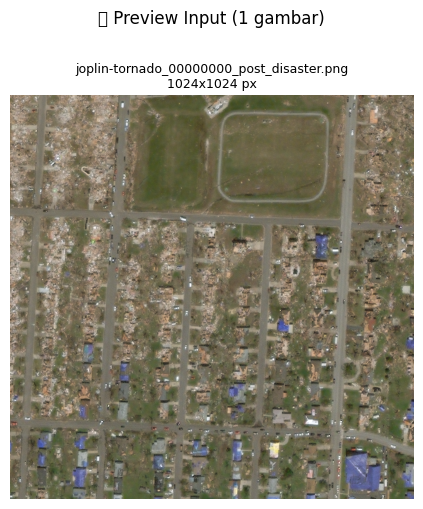


✅ Total 1 gambar siap diproses.


In [ ]:
# --- INPUT GAMBAR DINAMIS ---
import os
import matplotlib.pyplot as plt
from PIL import Image

images = []
IMAGE_PATHS = []

print('INPUT GAMBAR')
print('Masukkan path gambar satu per satu.')
print('Ketik "selesai" jika sudah.')
print('-' * 40)

while True:
    path = input('Path gambar: ').strip()
    if path.lower() == 'selesai':
        break
    if not os.path.exists(path):
        print(f'ERROR File tidak ditemukan: {path}')
        continue
    try:
        img = Image.open(path).convert('RGB')
        images.append(img)
        IMAGE_PATHS.append(path)
        print(f'  ✅ [{len(images)}] {os.path.basename(path)} | {img.size[0]}x{img.size[1]} px')
    except Exception as e:
        print(f'ERROR Gagal load: {e}')

if not images:
    print('ERROR: Tidak ada gambar yang diinput.')
else:
    # Preview semua gambar
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, img, path in zip(axes, images, IMAGE_PATHS):
        ax.imshow(img)
        ax.set_title(f'{os.path.basename(path)}\n{img.size[0]}x{img.size[1]} px', fontsize=9)
        ax.axis('off')
    plt.suptitle(f'!! Preview Input ({n} gambar) !!', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    print(f'\n✅ Total {n} gambar siap diproses.')

In [28]:
# --- INPUT PROMPT ---
print('INPUT PROMPT')
print('-' * 40)
prompt = input('Masukkan prompt: ').strip()
print(f'\n✅ Prompt diterima: "{prompt}"')

INPUT PROMPT
----------------------------------------


Masukkan prompt:  Apakah terlihat perbedaan warna atap yang signifikan antara bangunan utuh dan bangunan terdampak bencana?



✅ Prompt diterima: "Apakah terlihat perbedaan warna atap yang signifikan antara bangunan utuh dan bangunan terdampak bencana?"


In [ ]:
# ============================================================
# MoonDream2 — Kaggle Notebook
# HuggingFace: vikhyatk/moondream2
# Docs: https://docs.moondream.ai/
# ============================================================

# --- INSTALL ---
#!pip install -q transformers>=4.49.0 accelerate

In [29]:
# --- LOAD MODEL ---
import torch, gc, time
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = 'vikhyatk/moondream2'
REVISION  = '2025-01-09'
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    revision=REVISION,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map={'': DEVICE},
)
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    revision=REVISION,
    trust_remote_code=True,
)
print('✅ MoonDream2 loaded!')

✅ MoonDream2 loaded!


In [30]:
# --- INFERENSI ---
def run_moondream(images, image_paths, prompt):
    """
    Inferensi dinamis MoonDream2.
    - 1 gambar  : langsung query
    - >1 gambar : query per gambar, hasil digabung
    Output bahasa natural (Bahasa Inggris), tidak di-enforce.

    Catatan:
    - Tidak support multi-image natively (query per gambar)
    - Tidak support reasoning kuantitatif (perhitungan luas, area, dsb)
    - Cocok untuk deskripsi visual, identifikasi objek, klasifikasi scene
    """
    if len(images) == 1:
        enc = model.encode_image(images[0])
        return model.answer_question(enc, prompt, tokenizer)
    else:
        results = []
        for i, img in enumerate(images):
            enc = model.encode_image(img)
            ans = model.answer_question(enc, prompt, tokenizer)
            label = os.path.basename(image_paths[i])
            results.append(f'[Gambar {i+1} — {label}]\n{ans}')
        return '\n\n'.join(results)


# --- RUN ---
t0 = time.time()
result = run_moondream(images, IMAGE_PATHS, prompt)
print(f'\n Prompt : {prompt}')
print(f'Output ({time.time()-t0:.1f}s):')
print('-' * 55)
print(result)
print('-' * 55)


 Prompt : Apakah terlihat perbedaan warna atap yang signifikan antara bangunan utuh dan bangunan terdampak bencana?
Output (1.4s):
-------------------------------------------------------
Warna atap yang signifikan antara bangunan utuh dan bangunan terdampak bencana
-------------------------------------------------------


In [27]:
# --- CLEANUP ---
del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
print('Model dibersihkan dari VRAM')

Model dibersihkan dari VRAM
